# Round 3 — Data Exploration

Loads raw `prices_round_3_day_*.csv` and `trades_round_3_day_*.csv` from `backtester/datasets/round3/`.

Products:
- **VELVETFRUIT_EXTRACT** — underlying
- **HYDROGEL_PACK** — side product
- **VEV_K** for K in {4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500} — call vouchers struck at K

In [23]:
# --- Config ---
DATASET_DIR = "../backtester/datasets/round3/"
DAYS = [0, 1, 2]

UNDERLYING = "VELVETFRUIT_EXTRACT"
HELPER = "HYDROGEL_PACK"
VOUCHER_STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{k}" for k in VOUCHER_STRIKES]

In [24]:
import csv
import math
import statistics
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "monospace",
})

print("Ready.")

Ready.


## 1. Load Prices (order book snapshots)

In [25]:
def _num(x):
    if x in (None, ""):
        return None
    try:
        return float(x)
    except ValueError:
        return None

def load_prices(dataset_dir, days):
    rows = []
    for d in days:
        path = Path(dataset_dir) / f"prices_round_3_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        with open(path) as f:
            for r in csv.DictReader(f, delimiter=";"):
                r["_day"] = d
                r["_global_ts"] = d * 1_000_000 + int(r["timestamp"])
                r["_mid"] = _num(r.get("mid_price"))
                r["_bid1"] = _num(r.get("bid_price_1"))
                r["_ask1"] = _num(r.get("ask_price_1"))
                rows.append(r)
    return rows

prices = load_prices(DATASET_DIR, DAYS)
print(f"Loaded {len(prices):,} price rows")
if prices:
    products = sorted(set(r["product"] for r in prices))
    print(f"Products ({len(products)}): {products}")

Loaded 360,000 price rows
Products (12): ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


## 2. Underlying mid price (VELVETFRUIT_EXTRACT)

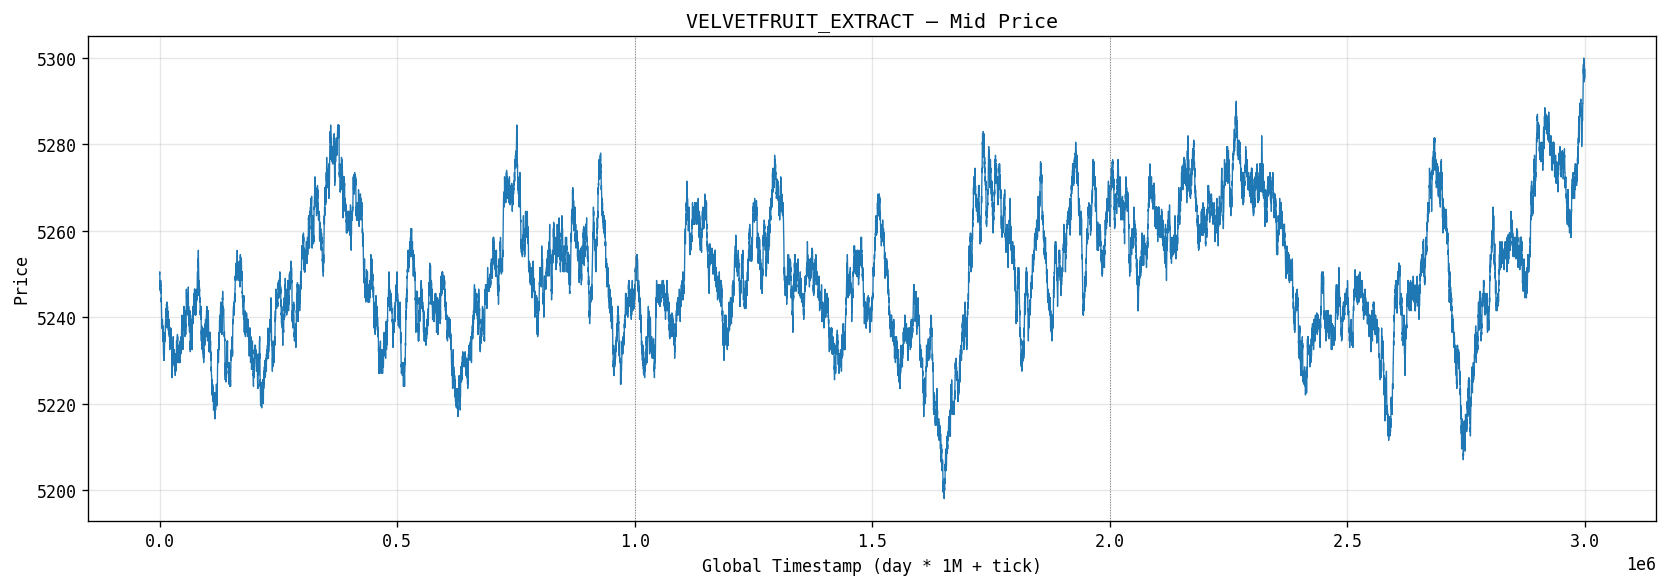

VELVETFRUIT_EXTRACT: n=30,000  mean=5250.10  min=5198.0  max=5300.0  stdev=15.63


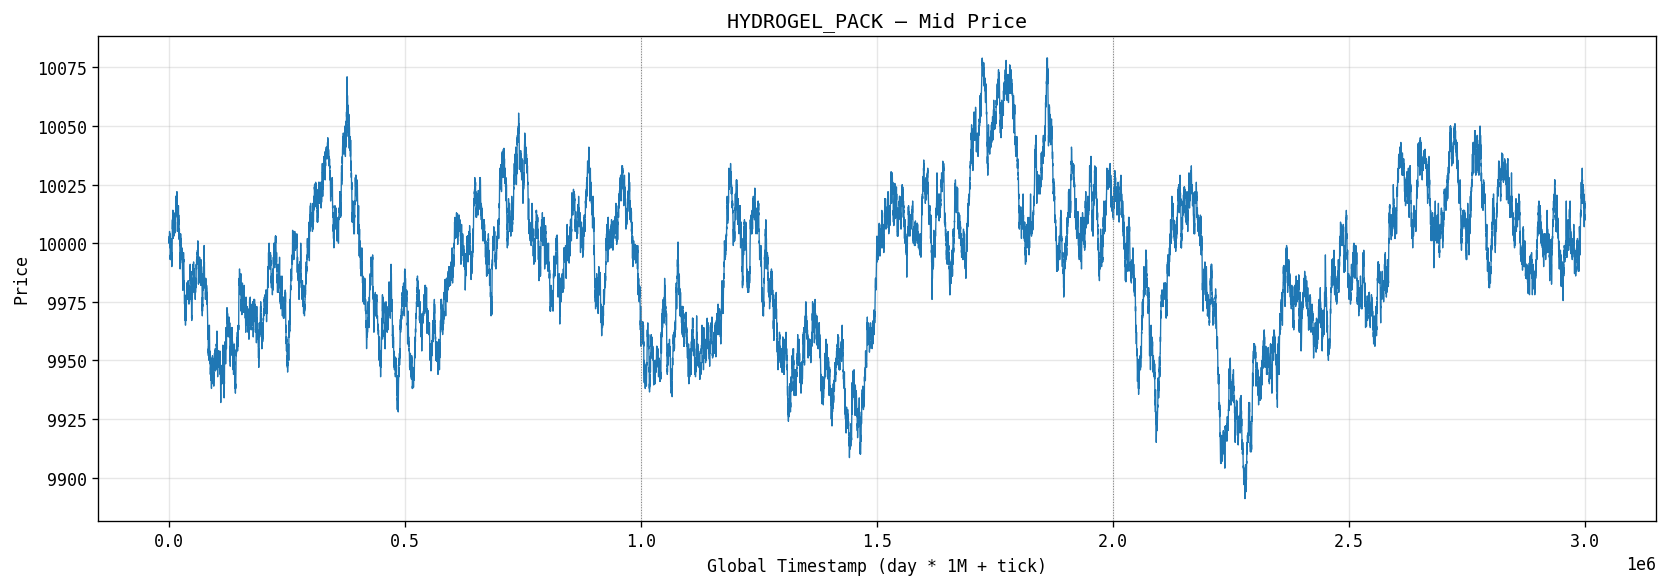

HYDROGEL_PACK: n=30,000  mean=9990.81  min=9891.0  max=10079.0  stdev=31.94


In [26]:
def series_for(product, rows):
    out = [(r["_global_ts"], r["_mid"]) for r in rows if r["product"] == product and r["_mid"] is not None]
    out.sort()
    return out

if prices:
    for prod in (UNDERLYING, HELPER):
        data = series_for(prod, prices)
        if not data:
            print(f"No data for {prod}")
            continue
        fig, ax = plt.subplots()
        ax.plot([d[0] for d in data], [d[1] for d in data], linewidth=0.8)
        for d in DAYS[1:]:
            ax.axvline(d * 1_000_000, color="gray", linestyle=":", linewidth=0.6)
        ax.set_title(f"{prod} — Mid Price")
        ax.set_xlabel("Global Timestamp (day * 1M + tick)")
        ax.set_ylabel("Price")
        plt.tight_layout()
        plt.show()

        vals = [v for _, v in data]
        print(f"{prod}: n={len(vals):,}  mean={statistics.mean(vals):.2f}  min={min(vals):.1f}  max={max(vals):.1f}  stdev={statistics.stdev(vals):.2f}")


## 3. Voucher mid prices — all strikes overlaid

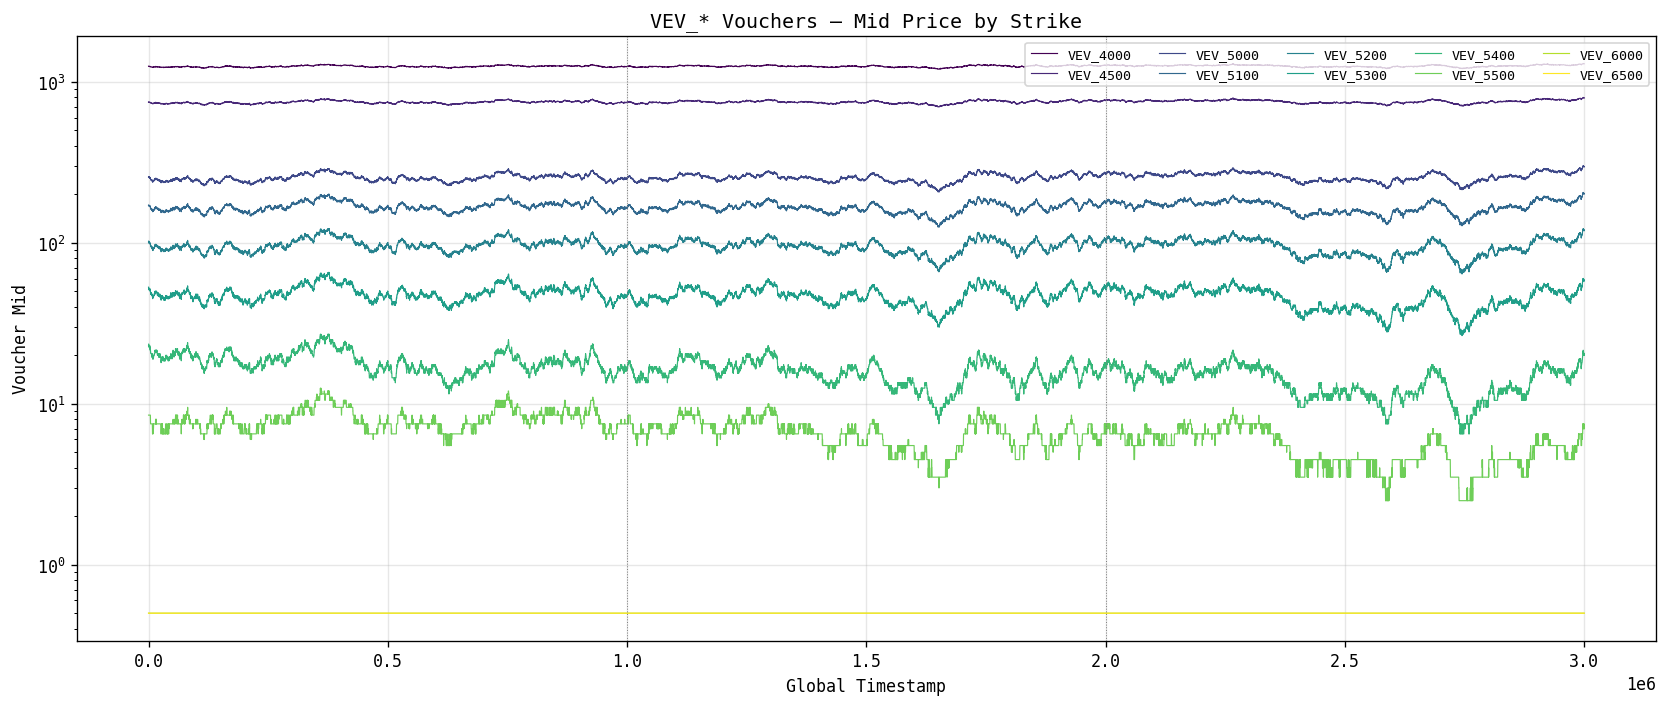

In [27]:
if prices:
    fig, ax = plt.subplots(figsize=(14, 6))
    cmap = plt.get_cmap("viridis")
    for i, v in enumerate(VOUCHERS):
        data = series_for(v, prices)
        if not data:
            continue
        color = cmap(i / max(1, len(VOUCHERS) - 1))
        ax.plot([d[0] for d in data], [d[1] for d in data], linewidth=0.7, color=color, label=v)
    for d in DAYS[1:]:
        ax.axvline(d * 1_000_000, color="gray", linestyle=":", linewidth=0.6)
    ax.set_title("VEV_* Vouchers — Mid Price by Strike")
    ax.set_xlabel("Global Timestamp")
    ax.set_ylabel("Voucher Mid")
    ax.set_yscale("log")
    ax.legend(ncol=5, fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

## 4. Intrinsic vs market voucher price

For a call struck at `K` on underlying `S`, intrinsic = `max(S − K, 0)`. Difference `market − intrinsic` is the extrinsic (time) value — should be non-negative and decays as you move deep ITM or far OTM.

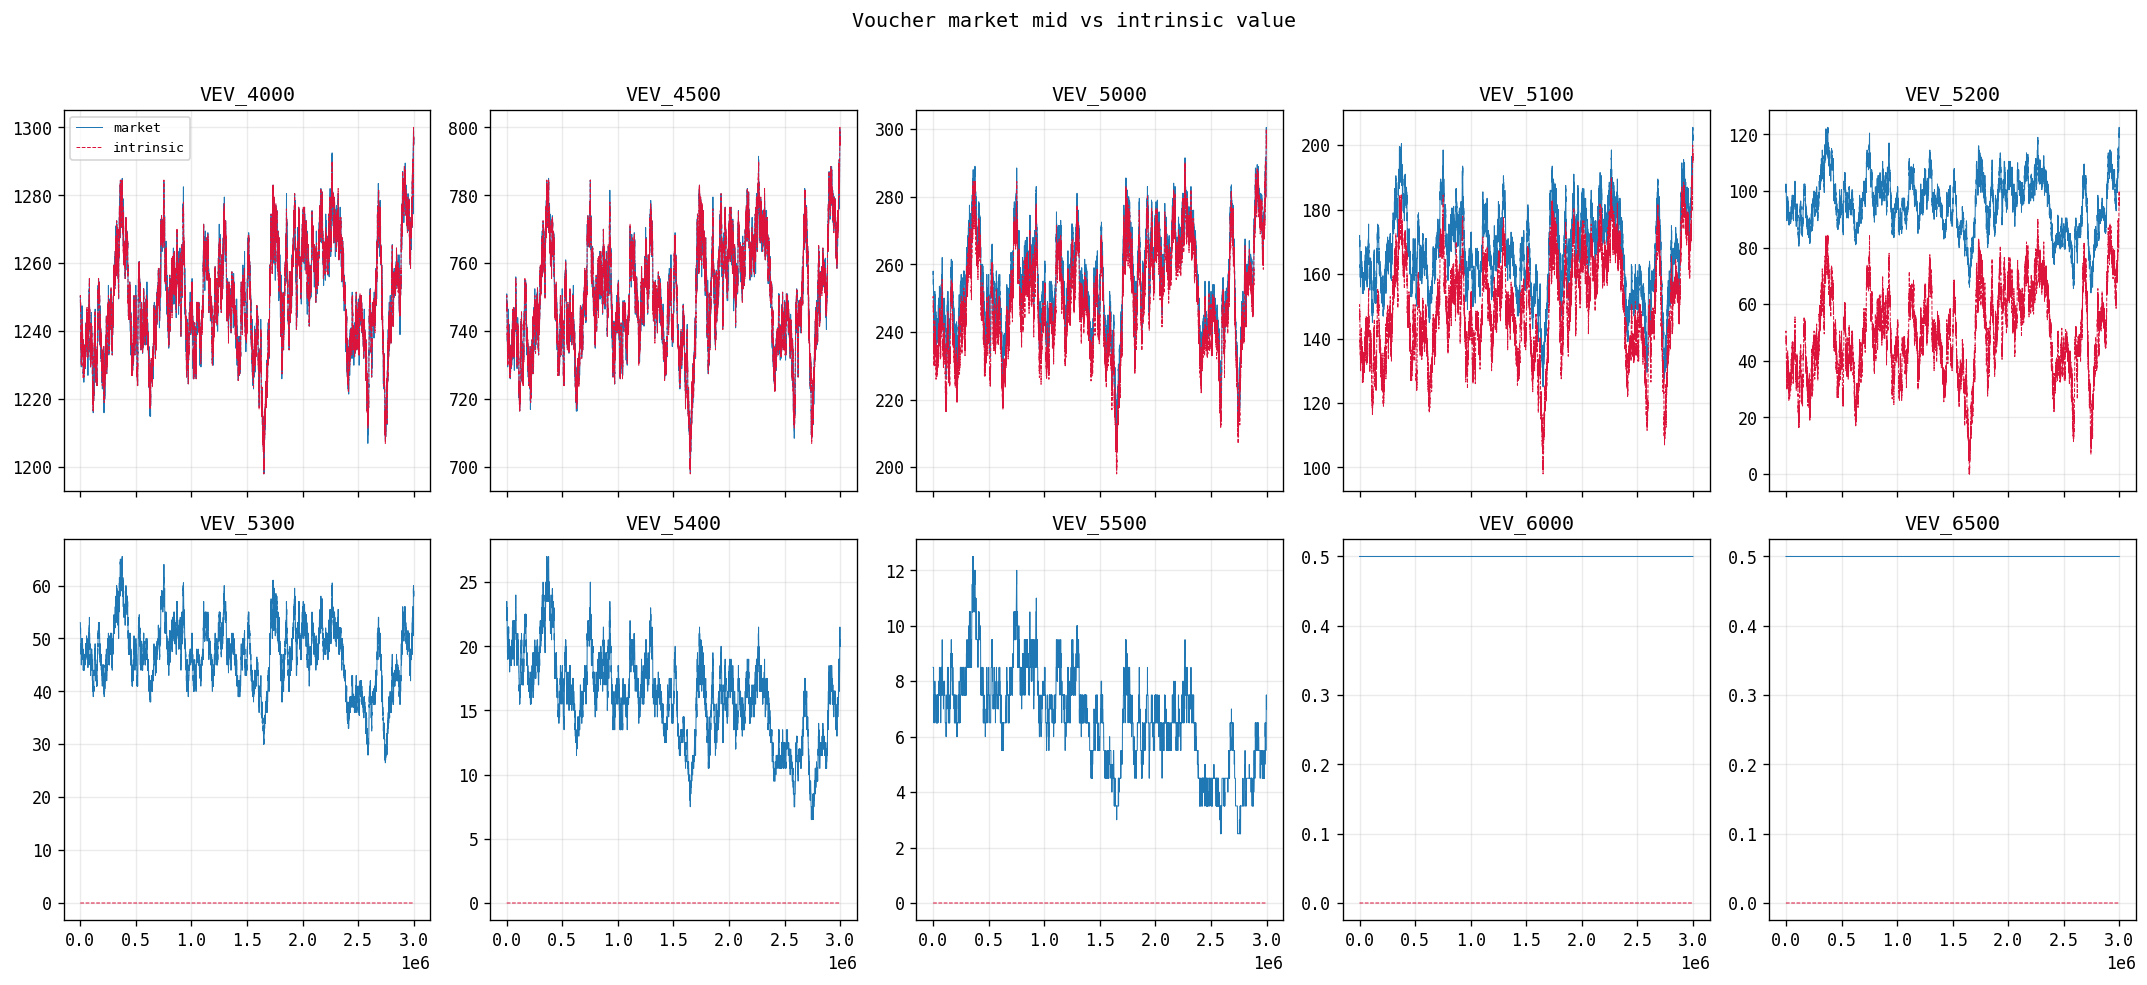

In [28]:
if prices:
    # Build a ts -> underlying mid lookup
    u_by_ts = {ts: mid for ts, mid in series_for(UNDERLYING, prices)}

    fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True)
    for ax, (strike, voucher) in zip(axes.flat, zip(VOUCHER_STRIKES, VOUCHERS)):
        data = series_for(voucher, prices)
        if not data:
            ax.set_title(f"{voucher} — no data")
            continue
        ts_arr = [t for t, _ in data]
        mkt    = [m for _, m in data]
        intr   = [max((u_by_ts.get(t) or 0) - strike, 0) for t in ts_arr]
        ax.plot(ts_arr, mkt, linewidth=0.6, label="market")
        ax.plot(ts_arr, intr, linewidth=0.6, linestyle="--", label="intrinsic", color="crimson")
        ax.set_title(f"VEV_{strike}")
        ax.grid(True, alpha=0.25)
    axes.flat[0].legend(fontsize=8, loc="upper left")
    fig.suptitle("Voucher market mid vs intrinsic value", y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Moneyness smile snapshot (extrinsic value by strike)

Pick a timestamp, plot `market_mid − intrinsic` across strikes. A sensible options market should show a hump near ATM.

Snapshot t=500,000  underlying=5249.5


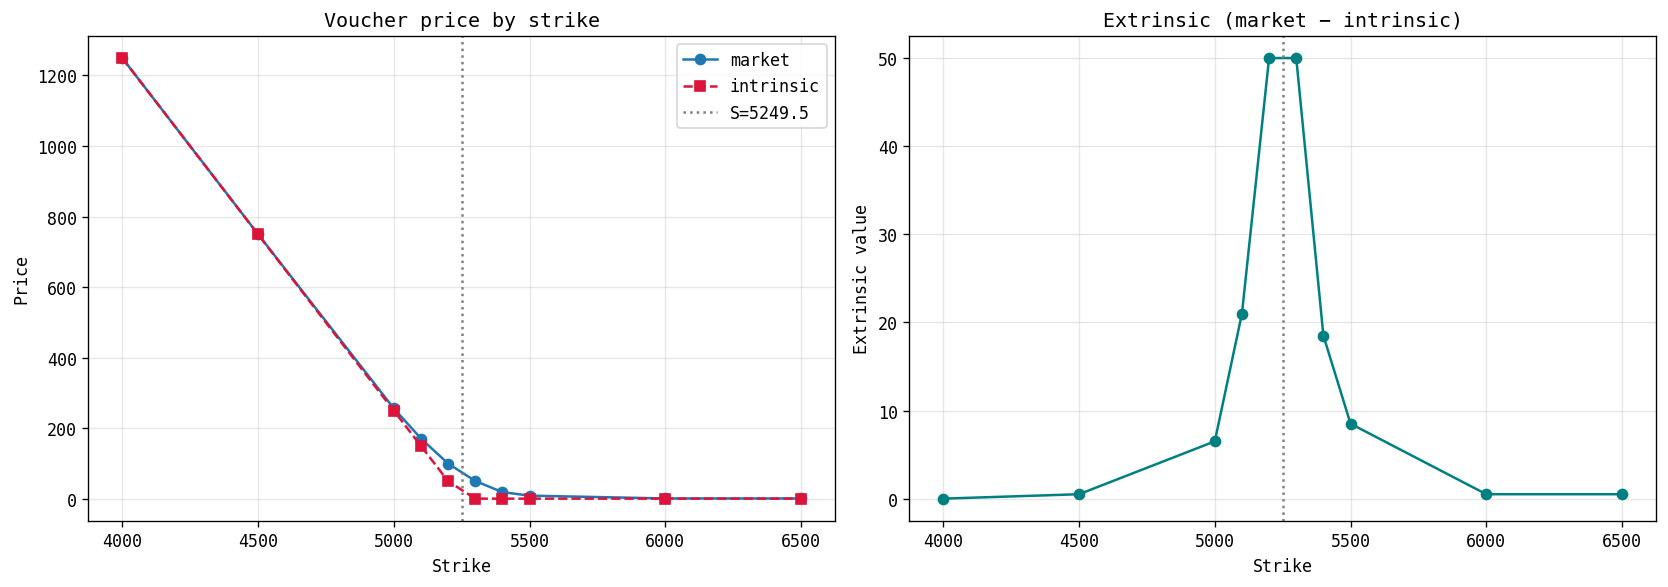

In [29]:
SNAPSHOT_DAY = 0
SNAPSHOT_TICK = 500_000  # midday of chosen day
snap_ts = SNAPSHOT_DAY * 1_000_000 + SNAPSHOT_TICK

if prices:
    # Nearest-available snapshot per product
    def snap_mid(product):
        ser = series_for(product, prices)
        if not ser:
            return None
        # Binary-ish nearest by ts
        best = min(ser, key=lambda r: abs(r[0] - snap_ts))
        return best[1] if abs(best[0] - snap_ts) <= 5000 else None

    S = snap_mid(UNDERLYING)
    print(f"Snapshot t={snap_ts:,}  underlying={S}")
    strikes, mkts, intrs, extrs = [], [], [], []
    for k, v in zip(VOUCHER_STRIKES, VOUCHERS):
        m = snap_mid(v)
        if m is None or S is None:
            continue
        intrinsic = max(S - k, 0)
        strikes.append(k); mkts.append(m); intrs.append(intrinsic); extrs.append(m - intrinsic)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(strikes, mkts, "o-", label="market")
    ax1.plot(strikes, intrs, "s--", label="intrinsic", color="crimson")
    if S is not None:
        ax1.axvline(S, color="gray", linestyle=":", label=f"S={S:.1f}")
    ax1.set_title("Voucher price by strike")
    ax1.set_xlabel("Strike"); ax1.set_ylabel("Price"); ax1.legend()
    ax2.plot(strikes, extrs, "o-", color="teal")
    if S is not None:
        ax2.axvline(S, color="gray", linestyle=":")
    ax2.set_title("Extrinsic (market − intrinsic)")
    ax2.set_xlabel("Strike"); ax2.set_ylabel("Extrinsic value")
    plt.tight_layout()
    plt.show()

## 6. Bid/Ask spread per product

In [30]:
if prices:
    rows = []
    for prod in [UNDERLYING, HELPER, *VOUCHERS]:
        spreads = [r["_ask1"] - r["_bid1"] for r in prices
                   if r["product"] == prod and r["_bid1"] is not None and r["_ask1"] is not None]
        if not spreads:
            continue
        rows.append((prod, len(spreads), statistics.mean(spreads), min(spreads), max(spreads)))
    rows.sort(key=lambda x: -x[2])
    print(f"{'product':25s} {'n':>8s} {'mean':>8s} {'min':>6s} {'max':>6s}")
    for p, n, mu, mn, mx in rows:
        print(f"{p:25s} {n:>8,d} {mu:>8.2f} {mn:>6.1f} {mx:>6.1f}")

product                          n     mean    min    max
VEV_4000                    30,000    20.81    9.0   22.0
VEV_4500                    30,000    15.85    7.0   17.0
HYDROGEL_PACK               30,000    15.72    7.0   17.0
VEV_5000                    30,000     6.04    2.0    7.0
VELVETFRUIT_EXTRACT         30,000     4.99    1.0    6.0
VEV_5100                    30,000     4.30    1.0    6.0
VEV_5200                    30,000     2.89    1.0    4.0
VEV_5300                    30,000     2.11    1.0    3.0
VEV_5400                    30,000     1.38    1.0    2.0
VEV_5500                    30,000     1.15    1.0    2.0
VEV_6000                    30,000     1.00    1.0    1.0
VEV_6500                    30,000     1.00    1.0    1.0


## 7. Load Trades

In [31]:
def load_trades(dataset_dir, days):
    rows = []
    for d in days:
        path = Path(dataset_dir) / f"trades_round_3_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        with open(path) as f:
            sample = f.read(2048); f.seek(0)
            delim = ";" if sample.count(";") > sample.count(",") else ","
            for r in csv.DictReader(f, delimiter=delim):
                r["_day"] = d
                r["_global_ts"] = d * 1_000_000 + int(r["timestamp"])
                rows.append(r)
    return rows

trades = load_trades(DATASET_DIR, DAYS)
print(f"Loaded {len(trades):,} trades")
if trades:
    print(f"Columns: {list(trades[0].keys())}")

Loaded 4,048 trades
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', '_day', '_global_ts']


## 8. Trade volume & notional per product

In [32]:
if trades:
    sym_key = "symbol" if "symbol" in trades[0] else "product"
    vol = defaultdict(int)
    notional = defaultdict(float)
    for t in trades:
        try:
            q = abs(int(float(t.get("quantity", 0))))
            p = float(t.get("price", 0))
        except (ValueError, TypeError):
            continue
        vol[t[sym_key]] += q
        notional[t[sym_key]] += q * p
    print(f"{'product':25s} {'volume':>10s} {'notional':>15s}")
    for p, v in sorted(vol.items(), key=lambda x: -x[1]):
        print(f"{p:25s} {v:>10,d} {notional[p]:>15,.0f}")

product                       volume        notional
VELVETFRUIT_EXTRACT            8,269      43,415,740
HYDROGEL_PACK                  4,078      40,742,275
VEV_6000                       1,002               0
VEV_6500                       1,002               0
VEV_4000                         940       1,174,738
VEV_5500                         937           5,572
VEV_5400                         787          11,699
VEV_5300                         420          18,651
VEV_5200                          63           5,390
VEV_4500                           1             733
VEV_5000                           1             238
VEV_5100                           1             152


## 9. Underlying log-returns (short-horizon)

Realized vol estimate from 1-tick log-returns on the underlying mid, annualized against a 10,000-tick "day".

1-tick log-return  mean=2.88e-07  stdev=2.1547e-04  n=29,999
Implied per-day vol (stdev * sqrt(10,000 ticks)) = 0.0215  (2.15%)


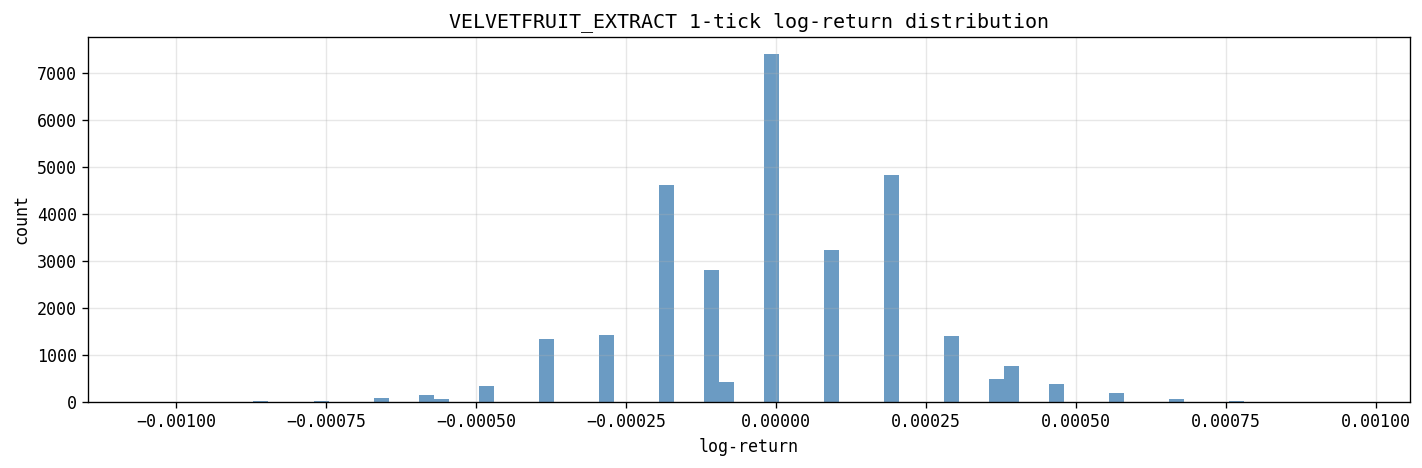

In [33]:
if prices:
    data = series_for(UNDERLYING, prices)
    logs = []
    for (t0, p0), (t1, p1) in zip(data, data[1:]):
        if t1 - t0 != 100 or p0 <= 0 or p1 <= 0:
            continue
        logs.append(math.log(p1 / p0))
    if logs:
        mu = statistics.mean(logs); sd = statistics.pstdev(logs)
        per_day = sd * math.sqrt(10_000)
        print(f"1-tick log-return  mean={mu:.2e}  stdev={sd:.4e}  n={len(logs):,}")
        print(f"Implied per-day vol (stdev * sqrt(10,000 ticks)) = {per_day:.4f}  ({per_day*100:.2f}%)")

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.hist(logs, bins=80, color="steelblue", alpha=0.8)
        ax.set_title(f"{UNDERLYING} 1-tick log-return distribution")
        ax.set_xlabel("log-return"); ax.set_ylabel("count")
        plt.tight_layout()
        plt.show()